# Prédiction du Prix de Vente d'une Voiture d'Occasion
## Notebook 1 : Analyse Exploratoire des Données (EDA)
**EHTP — MSDE Édition 7 | Module 5 : Machine Learning**
---

## I. Compréhension de la Problématique

### I.1 Problème Métier
Le marché des voitures d'occasion est difficile à estimer pour les acheteurs et vendeurs.
Le Machine Learning permet d'apprendre les patterns historiques pour prédire le prix `price`.

**Tâche ML :** Régression supervisée  
**Variable cible :** `price` (valeur numérique continue en euros)

### I.2 État de l'Art
| Algorithme | Type | Avantage Principal |
|-----------|------|---------------|
| Régression Linéaire | Linéaire | Baseline interprétable |
| Ridge / Lasso | Linéaire Régularisée | Gère la multicolinéarité |
| Arbre de Décision | Arbre | Non-linéaire, interprétable |
| Random Forest | Ensemble (Bagging) | Robuste, gère les valeurs manquantes |
| Gradient Boosting | Ensemble (Boosting) | Haute précision |
| XGBoost | Ensemble (Boosting) | Rapide et régularisé |
| LightGBM | Ensemble (Boosting) | Très rapide sur grandes données |
| SVR | Noyau | Efficace en haute dimension |
| KNN Regressor | Instance | Simple, sans hypothèses |
| Réseau de Neurones | Deep Learning | Capture les patterns complexes |

## II. Chargement des Librairies

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

print("Librairies chargées avec succès")

Librairies chargées avec succès


## III. Chargement et Aperçu du Dataset

In [42]:
df = pd.read_csv('../data/autos.csv', encoding='latin-1')

print(f"Dimensions du dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
df.head(10)

Dimensions du dataset : 371,528 lignes × 21 colonnes


,index,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,0,2016-03-24 11:52:17,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,0,golf,150000,0,benzin,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,1,2016-03-24 10:58:45,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,190,NaN,125000,5,diesel,audi,ja,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2,2016-03-14 12:52:21,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,163,grand,125000,8,diesel,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,3,2016-03-17 16:54:04,GOLF_4_1_4__3TÃRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,75,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,69,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21
5,5,2016-04-04 17:36:23,BMW_316i___e36_Limousine___Bastlerfahrzeug__Ex...,privat,Angebot,650,test,limousine,1995,manuell,102,3er,150000,10,benzin,bmw,ja,2016-04-04 00:00:00,0,33775,2016-04-06 19:17:07
6,6,2016-04-01 20:48:51,Peugeot_206_CC_110_Platinum,privat,Angebot,2200,test,cabrio,2004,manuell,109,2_reihe,150000,8,benzin,peugeot,nein,2016-04-01 00:00:00,0,67112,2016-04-05 18:18:39
7,7,2016-03-21 18:54:38,VW_Derby_Bj_80__Scheunenfund,privat,Angebot,0,test,limousine,1980,manuell,50,andere,40000,7,benzin,volkswagen,nein,2016-03-21 00:00:00,0,19348,2016-03-25 16:47:58
8,8,2016-04-04 23:42:13,Ford_C___Max_Titanium_1_0_L_EcoBoost,privat,Angebot,14500,control,bus,2014,manuell,125,c_max,30000,8,benzin,ford,NaN,2016-04-04 00:00:00,0,94505,2016-04-04 23:42:13
9,9,2016-03-17 10:53:50,VW_Golf_4_5_tuerig_zu_verkaufen_mit_Anhaengerk...,privat,Angebot,999,test,kleinwagen,1998,manuell,101,golf,150000,0,NaN,volkswagen,NaN,2016-03-17 00:00:00,0,27472,2016-03-31 17:17:06


### III.1 Types des variables et valeurs manquantes

In [43]:
# Résumé complet des colonnes
summary = pd.DataFrame({
    'Type': df.dtypes,
    'Valeurs manquantes': df.isnull().sum(),
    '% manquant': (df.isnull().sum() / len(df) * 100).round(2),
    'Valeurs uniques': df.nunique(),
    'Exemple': df.iloc[0]
})
print(summary)

                       Type  Valeurs manquantes  % manquant  Valeurs uniques  \
index                 int64                   0       0.000           371528   
dateCrawled          object                   0       0.000           280500   
name                 object                   0       0.000           233531   
seller               object                   0       0.000                2   
offerType            object                   0       0.000                2   
price                 int64                   0       0.000             5597   
abtest               object                   0       0.000                2   
vehicleType          object               37869      10.190                8   
yearOfRegistration    int64                   0       0.000              155   
gearbox              object               20209       5.440                2   
powerPS               int64                   0       0.000              794   
model                object             

### III.2 Statistiques descriptives

In [44]:
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
index,371528.000000,185763.500000,107251.039743,0.000000,92881.750000,185763.500000,278645.250000,371527.000000
price,371528.000000,17295.141865,3587953.744411,0.000000,1150.000000,2950.000000,7200.000000,2147483647.000000
yearOfRegistration,371528.000000,2004.577997,92.866598,1000.000000,1999.000000,2003.000000,2008.000000,9999.000000
powerPS,371528.000000,115.549477,192.139578,0.000000,70.000000,105.000000,150.000000,20000.000000
kilometer,371528.000000,125618.688228,40112.337051,5000.000000,125000.000000,150000.000000,150000.000000,150000.000000
monthOfRegistration,371528.000000,5.734445,3.712412,0.000000,3.000000,6.000000,9.000000,12.000000
nrOfPictures,371528.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
postalCode,371528.000000,50820.667640,25799.082470,1067.000000,30459.000000,49610.000000,71546.000000,99998.000000


### III.3 Visualisation des valeurs manquantes

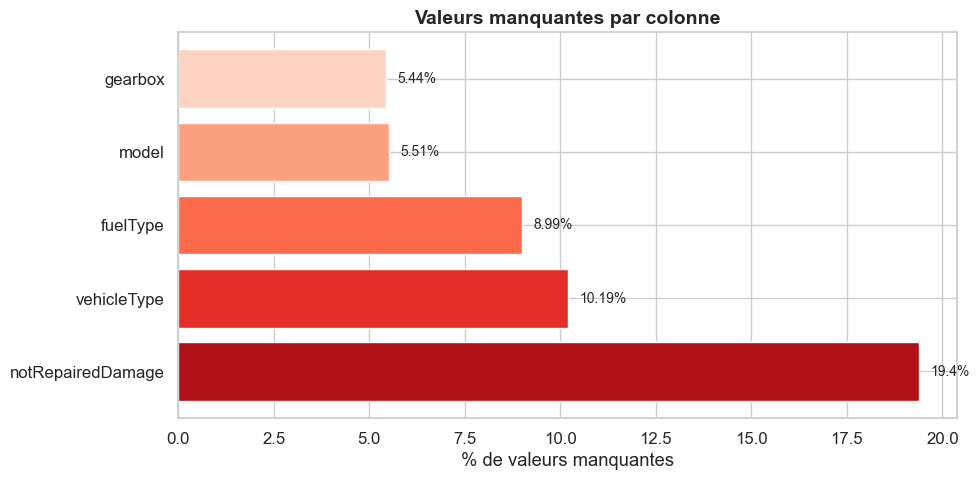

In [45]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing.index, missing_pct.values, color=sns.color_palette("Reds_r", len(missing)))
ax.set_xlabel('% de valeurs manquantes')
ax.set_title('Valeurs manquantes par colonne', fontsize=14, fontweight='bold')
for bar, val in zip(bars, missing_pct.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../report/valeurs_manquantes.png', dpi=150, bbox_inches='tight')
plt.show()

## IV. Analyse de la Variable Cible — `price`

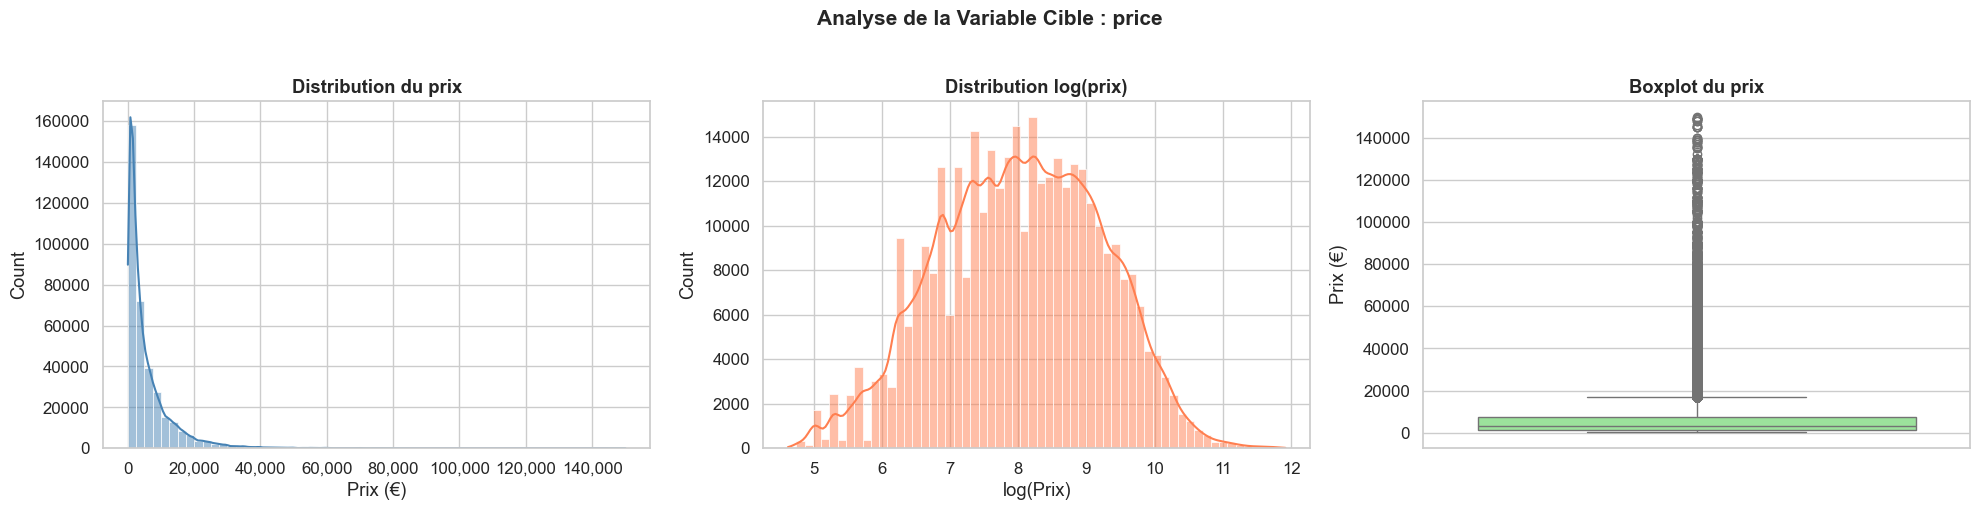

  Prix moyen    : 5,887 €
  Prix médian   : 3,100 €
  Prix minimum  : 101 €
  Prix maximum  : 149,999 €
  Écart-type    : 7,970 €
  Asymétrie     : 4.461
  Kurtosis      : 38.326


In [46]:
# Suppression des valeurs aberrantes extrêmes pour l'analyse visuelle
df_viz = df[(df['price'] > 100) & (df['price'] < 150000)].copy()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Distribution brute
sns.histplot(df_viz['price'], bins=60, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution du prix', fontweight='bold')
axes[0].set_xlabel('Prix (€)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Distribution log
sns.histplot(np.log1p(df_viz['price']), bins=60, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribution log(prix)', fontweight='bold')
axes[1].set_xlabel('log(Prix)')

# Boxplot
sns.boxplot(y=df_viz['price'], ax=axes[2], color='lightgreen')
axes[2].set_title('Boxplot du prix', fontweight='bold')
axes[2].set_ylabel('Prix (€)')

plt.suptitle('Analyse de la Variable Cible : price', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../report/distribution_prix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  Prix moyen    : {df_viz['price'].mean():,.0f} €")
print(f"  Prix médian   : {df_viz['price'].median():,.0f} €")
print(f"  Prix minimum  : {df_viz['price'].min():,.0f} €")
print(f"  Prix maximum  : {df_viz['price'].max():,.0f} €")
print(f"  Écart-type    : {df_viz['price'].std():,.0f} €")
print(f"  Asymétrie     : {df_viz['price'].skew():.3f}")
print(f"  Kurtosis      : {df_viz['price'].kurtosis():.3f}")

## V. Analyse des Variables Catégorielles

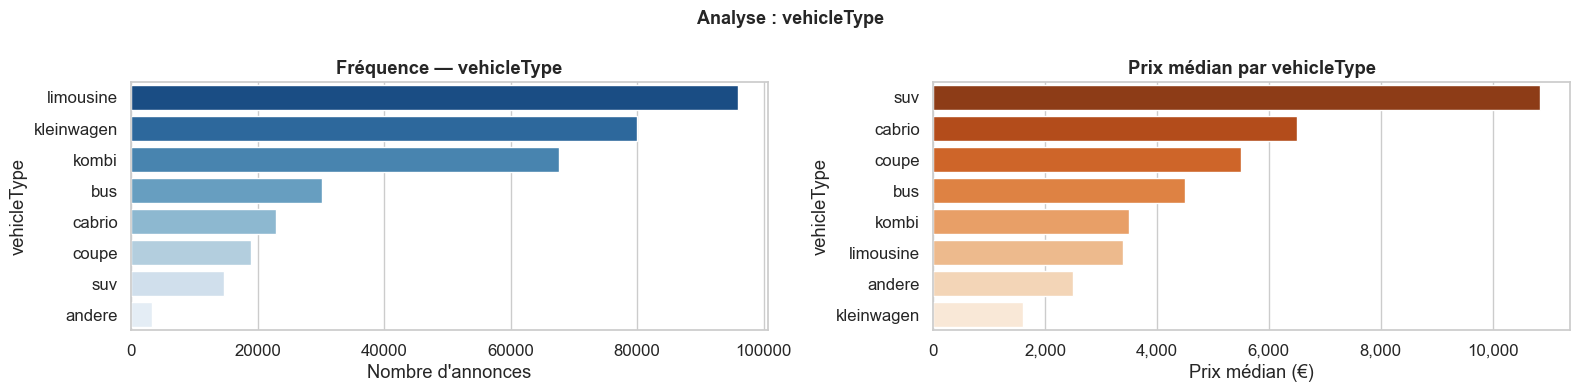

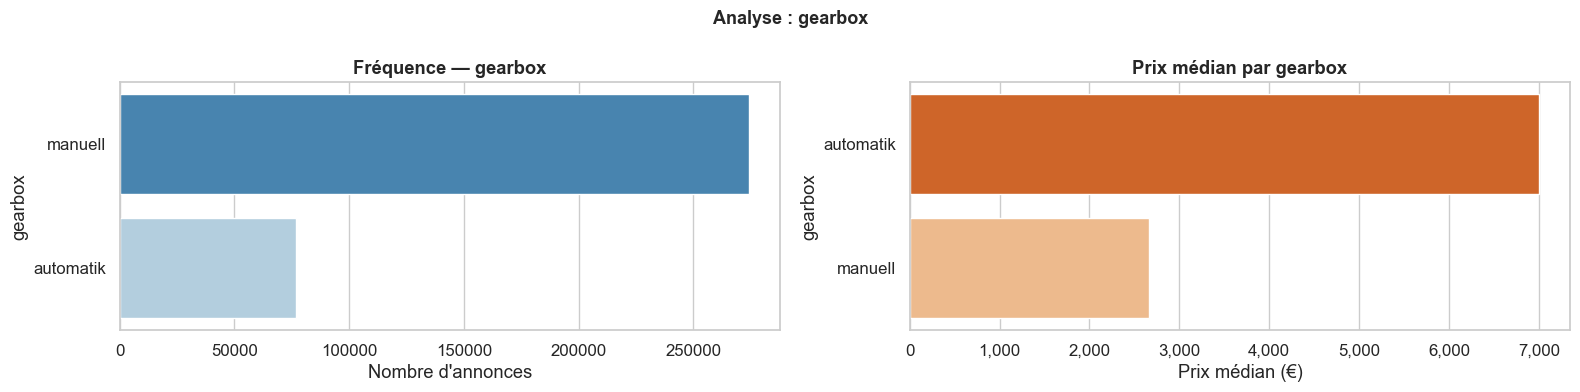

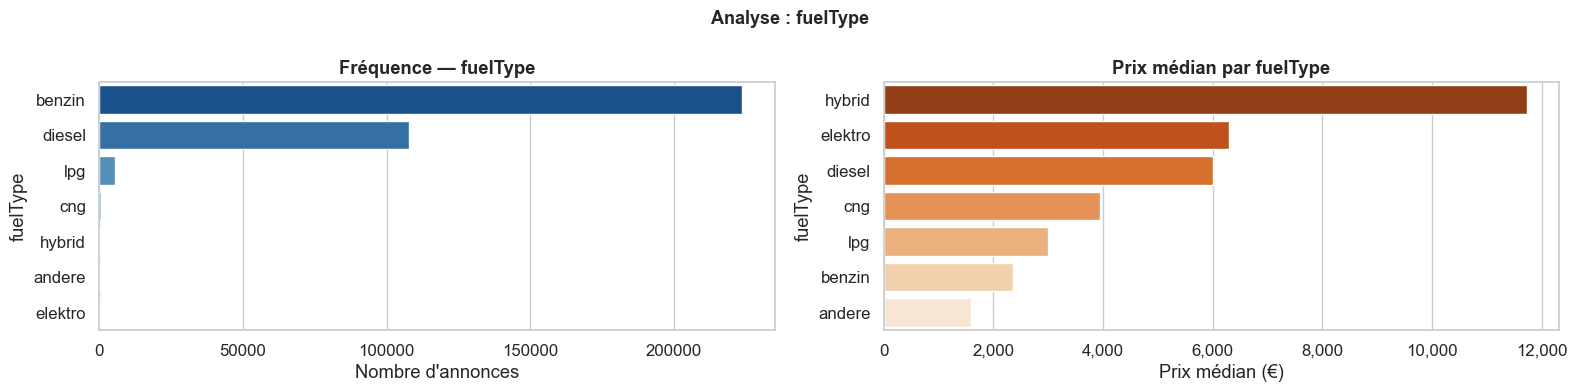

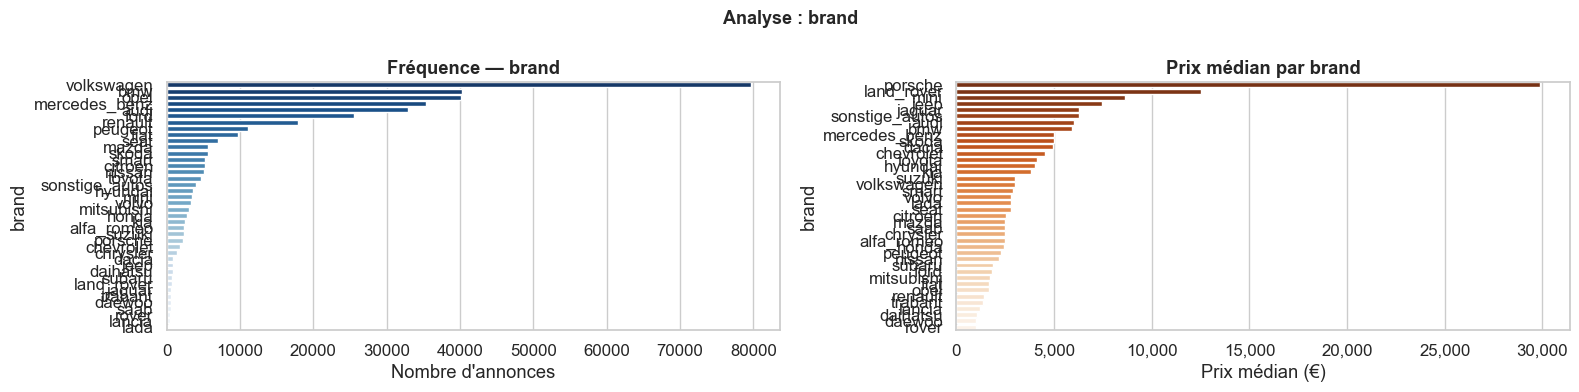

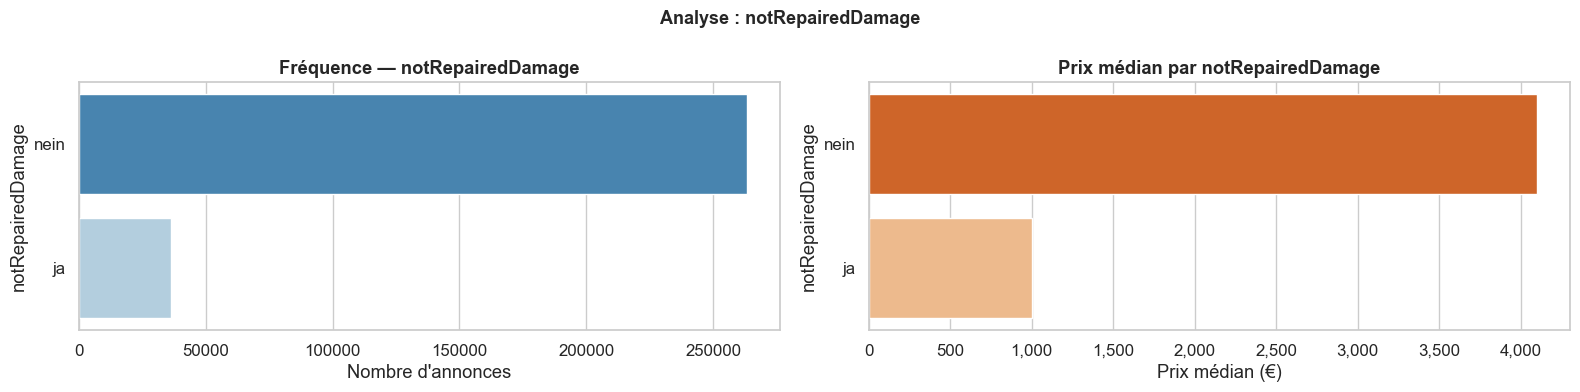

In [47]:
cat_cols = ['vehicleType', 'gearbox', 'fuelType', 'brand', 'notRepairedDamage']

for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # Fréquence
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=axes[0],
                  palette='Blues_r', edgecolor='white')
    axes[0].set_title(f'Fréquence — {col}', fontweight='bold')
    axes[0].set_xlabel('Nombre d\'annonces')

    # Prix médian par catégorie
    medians = df_viz.groupby(col)['price'].median().sort_values(ascending=False)
    sns.barplot(x=medians.values, y=medians.index, ax=axes[1],
                palette='Oranges_r', edgecolor='white')
    axes[1].set_title(f'Prix médian par {col}', fontweight='bold')
    axes[1].set_xlabel('Prix médian (€)')
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    plt.suptitle(f'Analyse : {col}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../report/cat_{col}.png', dpi=150, bbox_inches='tight')
    plt.show()

## VI. Analyse des Variables Numériques

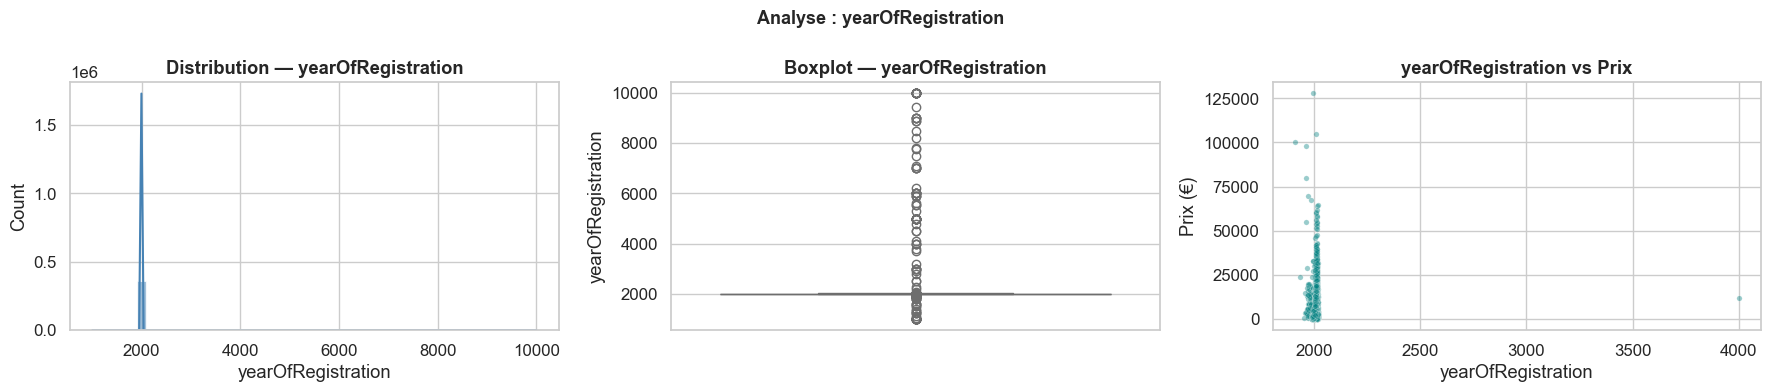

[yearOfRegistration] Moyenne: 2004.3 | Médiane: 2004.0 | Std: 73.2


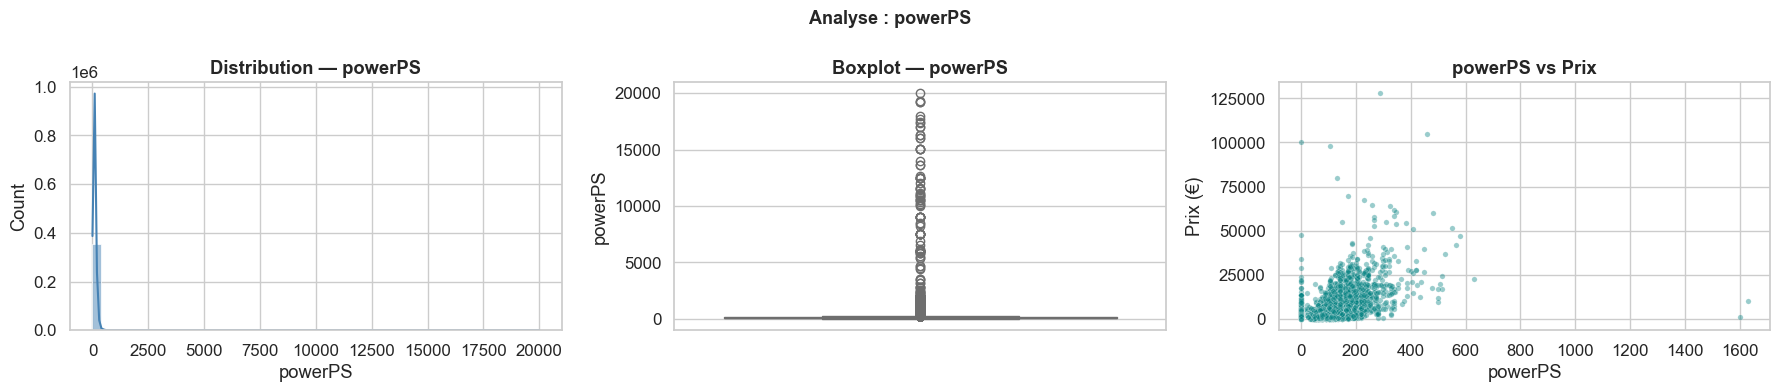

[powerPS] Moyenne: 117.0 | Médiane: 107.0 | Std: 190.1


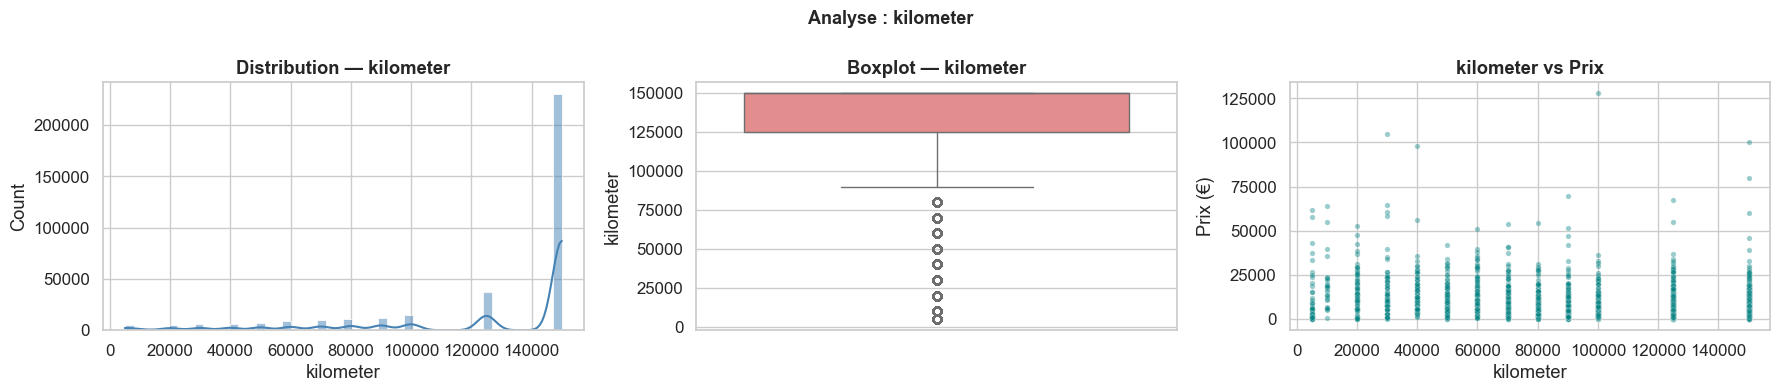

[kilometer] Moyenne: 125834.0 | Médiane: 150000.0 | Std: 39540.2


In [48]:
num_cols = ['yearOfRegistration', 'powerPS', 'kilometer']

for col in num_cols:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Distribution
    sns.histplot(df_viz[col].dropna(), bins=50, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title(f'Distribution — {col}', fontweight='bold')

    # Boxplot
    sns.boxplot(y=df_viz[col].dropna(), ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Boxplot — {col}', fontweight='bold')

    # Scatter vs price
    sns.scatterplot(data=df_viz.sample(min(5000, len(df_viz)), random_state=42),
                    x=col, y='price', alpha=0.4, ax=axes[2], color='teal', s=15)
    axes[2].set_title(f'{col} vs Prix', fontweight='bold')
    axes[2].set_ylabel('Prix (€)')

    plt.suptitle(f'Analyse : {col}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../report/num_{col}.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"[{col}] Moyenne: {df_viz[col].mean():.1f} | Médiane: {df_viz[col].median():.1f} | Std: {df_viz[col].std():.1f}")

## VII. Analyse des Corrélations

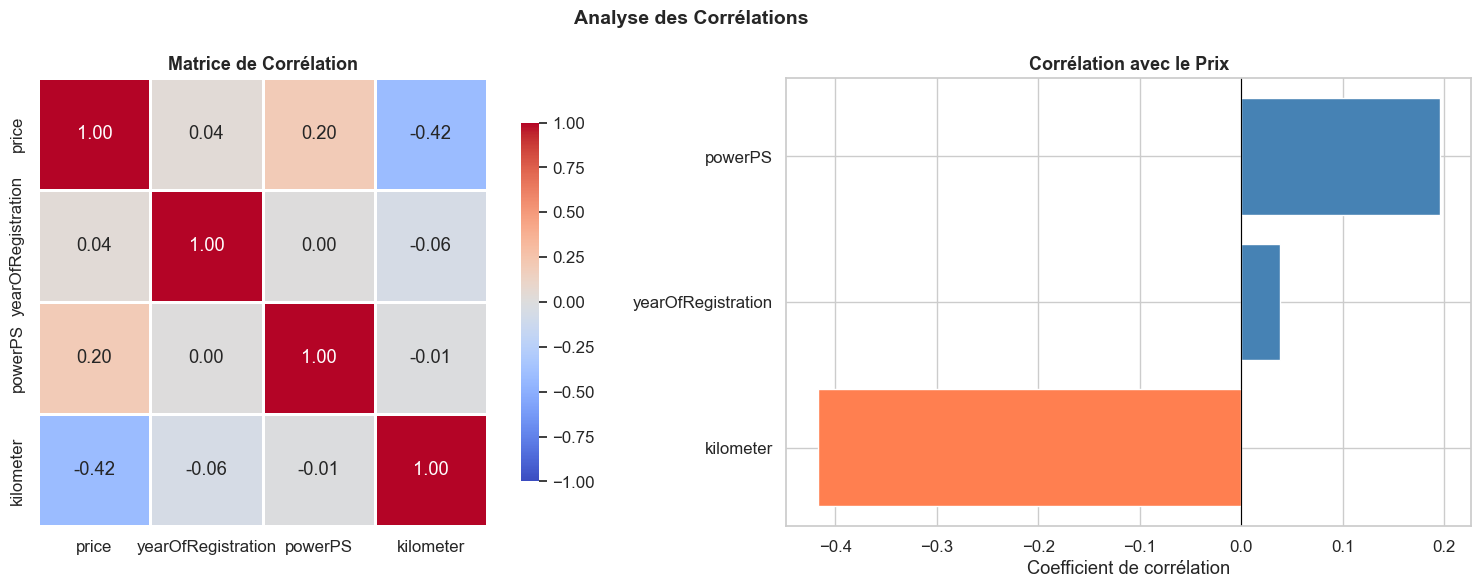

In [50]:
num_df = df_viz[['price', 'yearOfRegistration', 
                 'powerPS', 'kilometer']].dropna()
corr = num_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap complète
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.8, ax=axes[0],
            cbar_kws={"shrink": 0.8}, vmin=-1, vmax=1)
axes[0].set_title('Matrice de Corrélation', fontweight='bold', fontsize=13)

# Corrélation avec la cible uniquement
corr_target = corr['price'].drop('price').sort_values()
colors = ['coral' if v < 0 else 'steelblue' for v in corr_target.values]
axes[1].barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Corrélation avec le Prix', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Coefficient de corrélation')

plt.suptitle('Analyse des Corrélations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## VIII. Analyse des Outliers

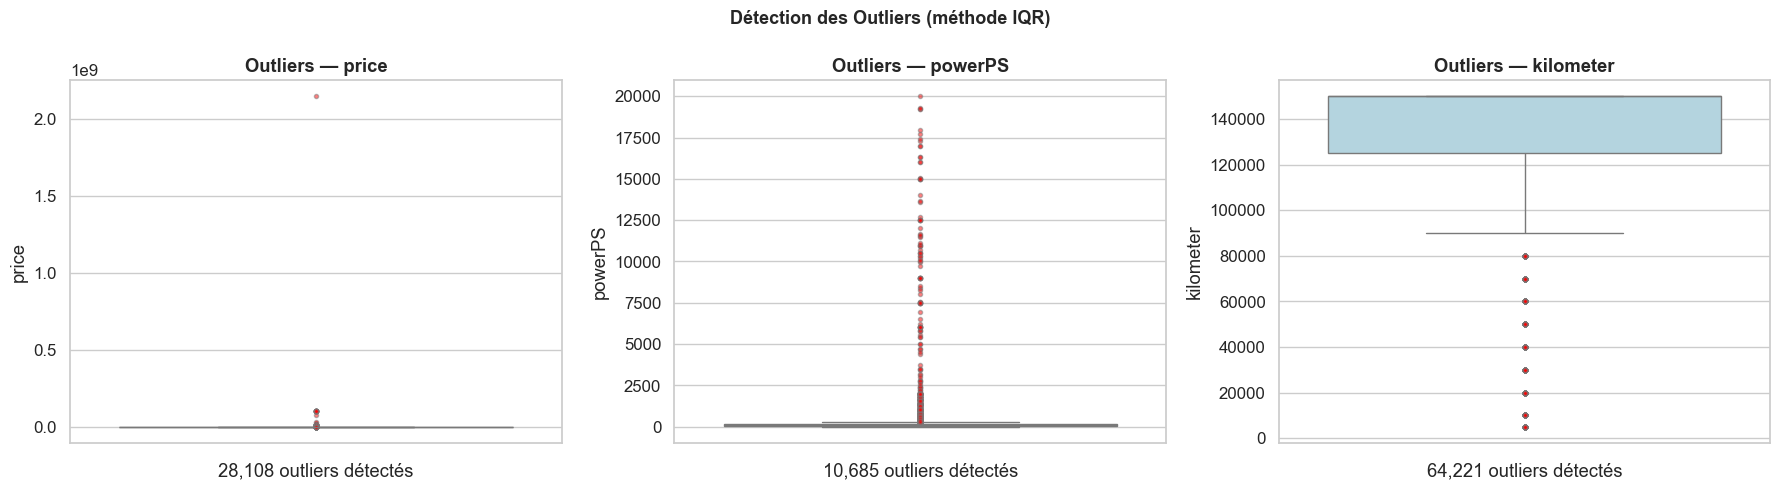

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cols_outliers = ['price', 'powerPS', 'kilometer']

for i, col in enumerate(cols_outliers):
    sns.boxplot(y=df[col], ax=axes[i], color='lightblue', flierprops=dict(
        marker='o', markerfacecolor='red', markersize=3, alpha=0.5))
    axes[i].set_title(f'Outliers — {col}', fontweight='bold')

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    axes[i].set_xlabel(f'{n_outliers:,} outliers détectés')

plt.suptitle('Détection des Outliers (méthode IQR)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/outliers.png', dpi=150, bbox_inches='tight')
plt.show()

## VIII.bis Analyse des Tendances Reelles par Tranche

Cette analyse valide que les relations entre features et prix
sont logiques et monotones dans les donnees reelles.
Elle guide les choix de preprocessing et de modelisation.

=== CORRELATIONS REELLES AVEC LE PRIX ===
  car_age         : r=-0.5329 | attendu=negatif | OK
  kilometer       : r=-0.4770 | attendu=negatif | OK
  powerPS         : r=+0.5719 | attendu=positif | OK


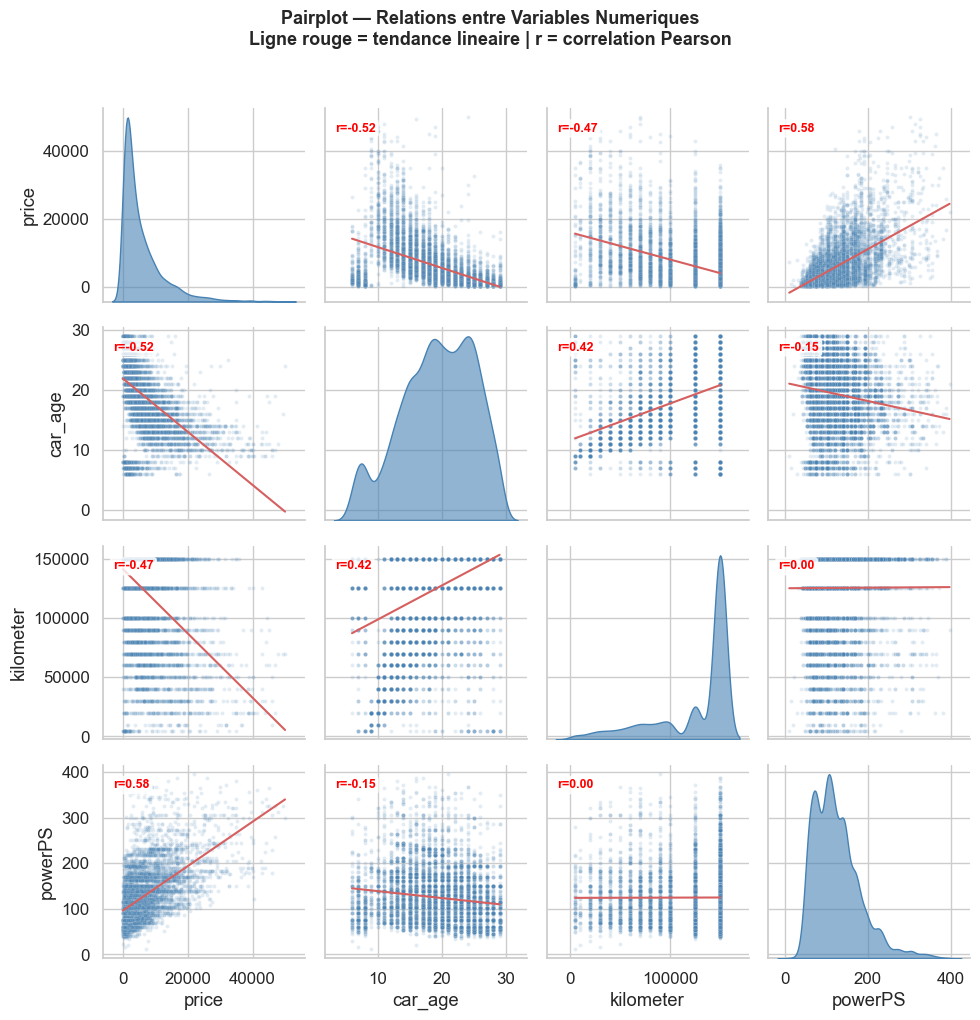

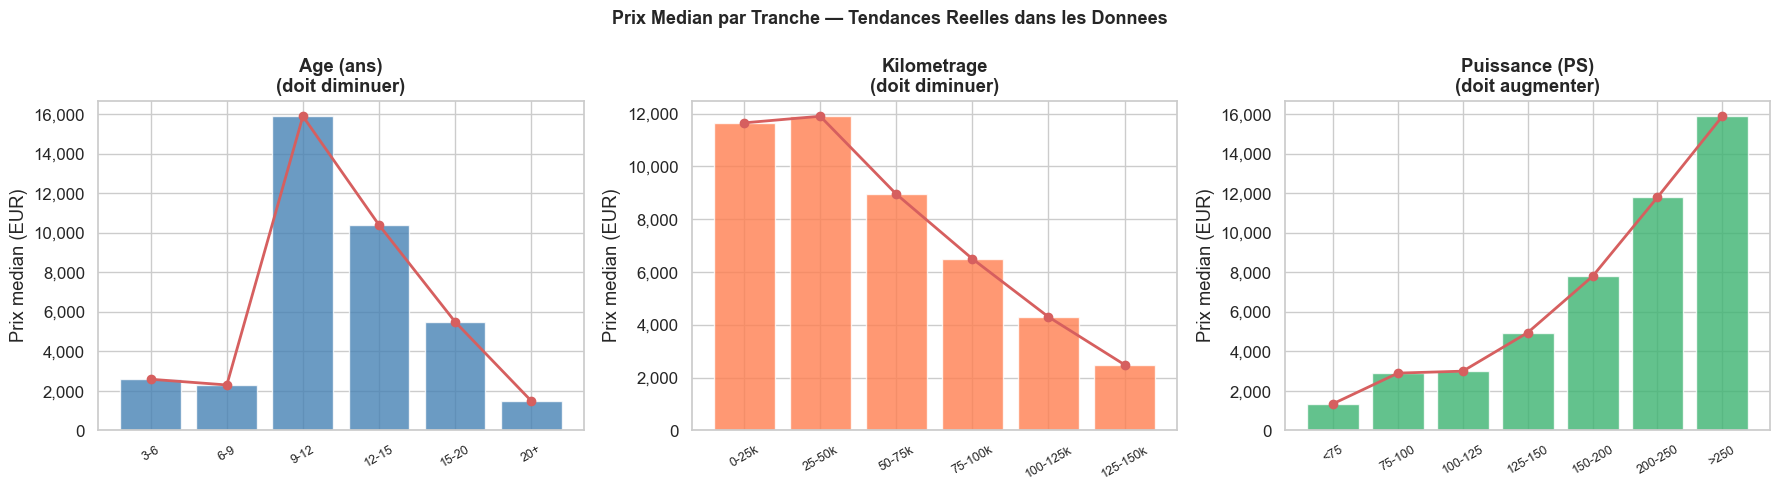


=== DIAGNOSTIC POUR LE PREPROCESSING ===
  car_age         monotone : NON — patterns aberrants
  kilometer       monotone : NON — patterns aberrants
  powerPS         monotone : OK ✓


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df['car_age'] = 2024 - df['yearOfRegistration']

df_clean = df[
    (df['price']     > 100)  & (df['price']     < 50000) &
    (df['powerPS']   > 10)   & (df['powerPS']   < 400)   &
    (df['car_age']   > 0)    & (df['car_age']   < 30)    &
    (df['kilometer'] >= 0)   & (df['kilometer'] <= 200000)
].copy()

df_sample = df_clean.sample(min(8000, len(df_clean)), random_state=42)

# Correlations reelles
print("=== CORRELATIONS REELLES AVEC LE PRIX ===")
for col in ['car_age', 'kilometer', 'powerPS']:
    corr     = df_clean['price'].corr(df_clean[col])
    attendu  = "negatif" if col != 'powerPS' else "positif"
    statut   = "OK" if (corr<0 and attendu=="negatif") or \
                       (corr>0 and attendu=="positif") else "PROBLEME"
    print(f"  {col:15s} : r={corr:+.4f} | attendu={attendu} | {statut}")

# Pairplot
num_vars = ['price', 'car_age', 'kilometer', 'powerPS']
g = sns.pairplot(
    df_sample[num_vars],
    diag_kind='kde',
    plot_kws={'alpha': 0.15, 'color': 'steelblue', 's': 8},
    diag_kws={'color': 'steelblue', 'fill': True, 'alpha': 0.6}
)
for i in range(len(num_vars)):
    for j in range(len(num_vars)):
        if i != j:
            ax = g.axes[i][j]
            x  = df_sample[num_vars[j]].values
            y  = df_sample[num_vars[i]].values
            try:
                z    = np.polyfit(x, y, 1)
                p_fn = np.poly1d(z)
                x_l  = np.linspace(x.min(), x.max(), 100)
                ax.plot(x_l, p_fn(x_l), 'r-', linewidth=1.5)
                corr = np.corrcoef(x, y)[0,1]
                ax.text(0.05, 0.88, f'r={corr:.2f}',
                        transform=ax.transAxes,
                        fontsize=9, color='red', fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.2',
                                  facecolor='white', alpha=0.8))
            except:
                pass
g.fig.suptitle(
    'Pairplot — Relations entre Variables Numeriques\n'
    'Ligne rouge = tendance lineaire | r = correlation Pearson',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../report/pairplot_complet.png', dpi=150, bbox_inches='tight')
plt.show()

# Prix median par tranche
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs = [
    ('car_age',   [0,3,6,9,12,15,20,30],
     ['0-3','3-6','6-9','9-12','12-15','15-20','20+'],
     'steelblue', 'Age (ans)', 'doit diminuer'),
    ('kilometer', [0,25000,50000,75000,100000,125000,150000,200000],
     ['0-25k','25-50k','50-75k','75-100k','100-125k','125-150k','150-200k'],
     'coral', 'Kilometrage', 'doit diminuer'),
    ('powerPS',   [0,75,100,125,150,200,250,400],
     ['<75','75-100','100-125','125-150','150-200','200-250','>250'],
     'mediumseagreen', 'Puissance (PS)', 'doit augmenter'),
]

for i, (col, bins, labels, color, xlabel, note) in enumerate(configs):
    df_clean['grp'] = pd.cut(df_clean[col], bins=bins, labels=labels)
    med = df_clean.groupby('grp', observed=True)['price'].median()
    axes[i].bar(range(len(med)), med.values,
                color=color, edgecolor='white', alpha=0.8)
    axes[i].plot(range(len(med)), med.values,
                 'ro-', linewidth=2, markersize=6)
    axes[i].set_xticks(range(len(med)))
    axes[i].set_xticklabels(med.index, rotation=30, fontsize=9)
    axes[i].set_ylabel('Prix median (EUR)')
    axes[i].set_title(f'{xlabel}\n({note})', fontweight='bold')
    axes[i].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Prix Median par Tranche — Tendances Reelles dans les Donnees',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/tendances_reelles.png', dpi=150, bbox_inches='tight')
plt.show()

# Diagnostic
print("\n=== DIAGNOSTIC POUR LE PREPROCESSING ===")
for col, bins, labels in [
    ('car_age',   [0,3,6,9,12,15,20,30],
     ['0-3','3-6','6-9','9-12','12-15','15-20','20+']),
    ('kilometer', [0,25000,50000,75000,100000,125000,150000,200000],
     ['0-25k','25-50k','50-75k','75-100k','100-125k','125-150k','150-200k']),
    ('powerPS',   [0,75,100,125,150,200,250,400],
     ['<75','75-100','100-125','125-150','150-200','200-250','>250']),
]:
    df_clean['grp'] = pd.cut(df_clean[col], bins=bins, labels=labels)
    vals = df_clean.groupby('grp', observed=True)['price'].median().values
    if col == 'powerPS':
        ok = all(vals[i] <= vals[i+1] for i in range(len(vals)-1))
    else:
        ok = all(vals[i] >= vals[i+1] for i in range(len(vals)-1))
    print(f"  {col:15s} monotone : {'OK ✓' if ok else 'NON — patterns aberrants'}")

## IX. Conclusions et Insights Clés

### Synthèse de l'EDA

**Variable cible `price` :**
- Distribution fortement asymétrique à droite → une transformation logarithmique sera appliquée en preprocessing
- Présence de nombreux outliers (prix = 0, prix > 100 000€) → nécessite un filtrage

**Variables catégorielles :**
- `brand` : les marques premium (BMW, Mercedes, Audi) affichent des prix médians nettement plus élevés
- `vehicleType` : les SUV et coupés sont plus chers que les petites citadines
- `gearbox` : les boîtes automatiques sont associées à des prix plus élevés
- `fuelType` : les voitures hybrides et électriques ont les prix les plus élevés
- `notRepairedDamage` : les voitures avec dommages non réparés valent significativement moins

**Variables numériques :**
- `yearOfRegistration` : forte corrélation positive avec le prix (plus récent = plus cher)
- `powerPS` : corrélation positive avec le prix (plus de puissance = plus cher)
- `kilometer` : corrélation négative avec le prix (plus de km = moins cher)

**Valeurs manquantes :**
- Plusieurs colonnes ont des valeurs manquantes → stratégie d'imputation requise en preprocessing

**Actions pour le Preprocessing :**
1. Filtrer les prix aberrants (price < 100 ou price > 100 000)
2. Filtrer les années aberrantes (yearOfRegistration < 1950 ou > 2024)
3. Filtrer powerPS aberrants (powerPS > 500)
4. Imputer les valeurs manquantes
5. Encoder les variables catégorielles
6. Appliquer log(price) comme variable cible
7. Supprimer les colonnes inutiles : nrOfPictures, postalCode, dateCrawled, dateCreated, lastSeen, abtest

In [53]:
import pandas as pd
import json
df = pd.read_csv('../data/autos.csv', encoding='latin-1')
brand_models = df.groupby('brand')['model'].apply(
    lambda x: x.value_counts().head(10).index.tolist()
).to_dict()
print(json.dumps(brand_models, indent=2))

{
  "alfa_romeo": [
    "156",
    "147",
    "andere",
    "159",
    "spider",
    "145"
  ],
  "audi": [
    "a4",
    "a3",
    "a6",
    "80",
    "andere",
    "tt",
    "a5",
    "a1",
    "a8",
    "q5"
  ],
  "bmw": [
    "3er",
    "5er",
    "1er",
    "x_reihe",
    "7er",
    "z_reihe",
    "andere",
    "m_reihe",
    "6er",
    "i3"
  ],
  "chevrolet": [
    "andere",
    "matiz",
    "captiva",
    "spark",
    "aveo"
  ],
  "chrysler": [
    "andere",
    "voyager",
    "ptcruiser",
    "300c",
    "grand",
    "crossfire"
  ],
  "citroen": [
    "andere",
    "berlingo",
    "c3",
    "c5",
    "c4",
    "c2",
    "c1"
  ],
  "dacia": [
    "logan",
    "sandero",
    "duster",
    "lodgy",
    "andere"
  ],
  "daewoo": [
    "matiz",
    "kalos",
    "andere",
    "lanos",
    "nubira"
  ],
  "daihatsu": [
    "cuore",
    "sirion",
    "andere",
    "move",
    "terios",
    "charade",
    "materia"
  ],
  "fiat": [
    "punto",
    "andere",
    "500",
    "panda",